In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(55).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(152).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(69).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(116).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(191).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(179).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(192).jpg
/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images/Healthy Leaf/Healthy_Leaf(38).jpg
/kaggle/input/project-datas

TensorFlow Version: 2.6.0+cu124
GPU is available and will be used.
Preprocessing Images...
Classes: ['Bacterial Leaf Disease', 'Dried Leaf', 'Fungal Brown Spot Disease', 'Healthy Leaf']

Dataset Split Ratios:
Train: 700 images (70.0%)
Validation: 150 images (15.0%)
Test: 150 images (15.0%)


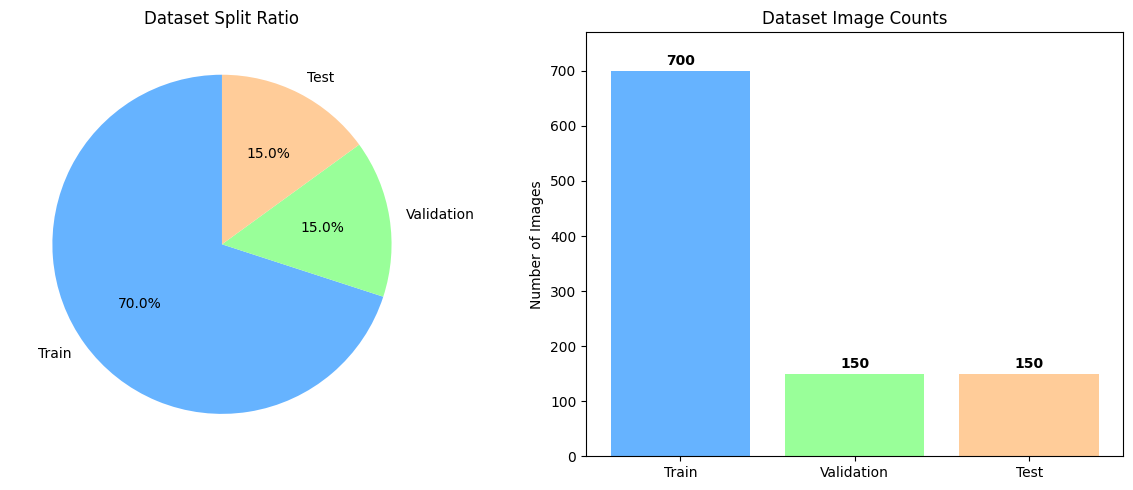


Class Distribution Across Splits:


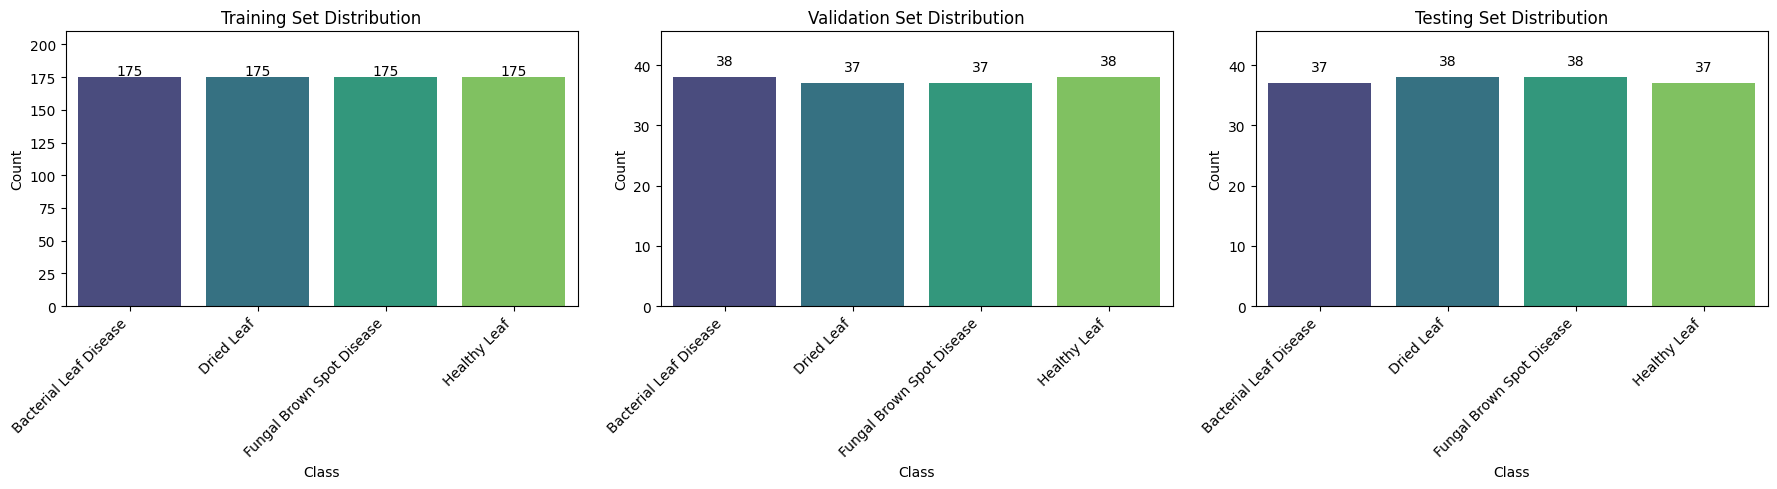


--- Initializing SE-ResNet50 Model ---

--- Training Started ---


Train:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 1: Train Acc 0.6943 | Val Acc 0.7533


Train:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 2: Train Acc 0.7757 | Val Acc 0.7200


...

Epoch 16: Train Acc 0.8871 | Val Acc 0.8667


Train:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 17: Train Acc 0.8771 | Val Acc 0.8733


Train:   0%|          | 0/22 [00:00<?, ?it/s]

Epoch 18: Train Acc 0.8900 | Val Acc 0.8933
Early Stopping.

--- Evaluation on Test Set ---
                           precision    recall  f1-score   support

   Bacterial Leaf Disease       0.76      0.84      0.79        37
               Dried Leaf       0.90      1.00      0.95        38
Fungal Brown Spot Disease       0.97      0.89      0.93        38
             Healthy Leaf       0.91      0.78      0.84        37

                 accuracy                           0.88       150
                macro avg       0.88      0.88      0.88       150
             weighted avg       0.89      0.88      0.88       150



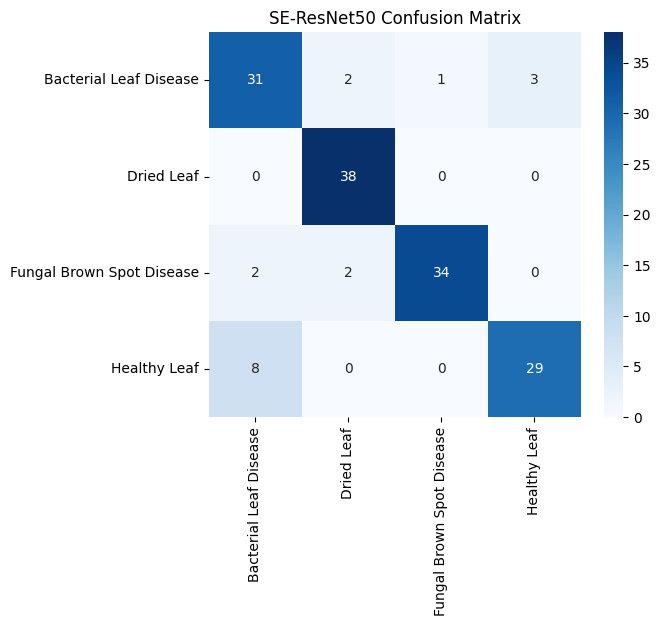


--- Calculating ROC & AUC ---


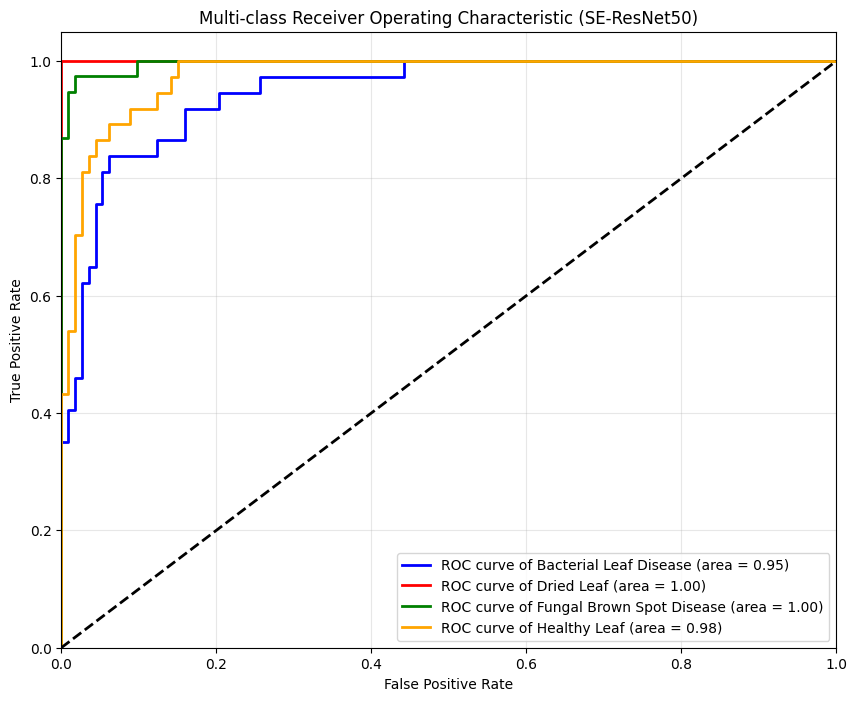


--- Grad-CAM Explainability ---


/tmp/ipykernel_20/1968706771.py:555: RuntimeWarning: invalid value encountered in cast
  heatmap = np.uint8(255 * heatmap)


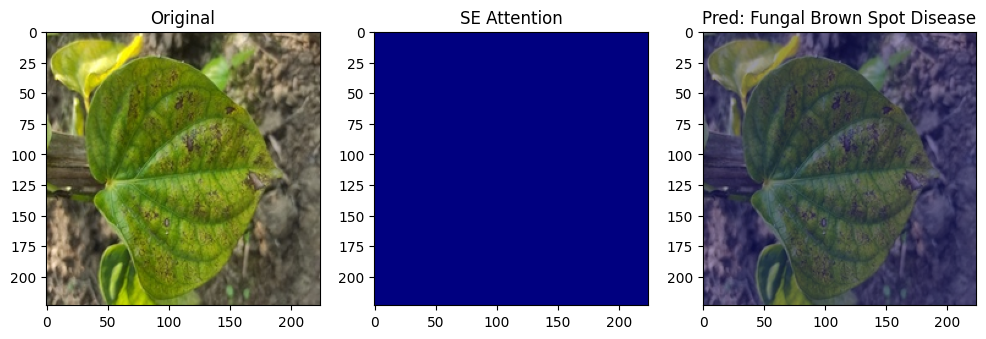

In [2]:
# ==============================================================================
# 0. INITIAL SETUP & IMPORTS
# ==============================================================================
!pip install torchinfo --quiet

import time
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import cv2
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import transforms
from torchinfo import summary
import torchvision.models as models
import torch.optim as optim
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image

print("TensorFlow Version:", torch.__version__)

# Check for GPU
if torch.cuda.is_available():
    print("GPU is available and will be used.")
    device = torch.device('cuda')
else:
    print("GPU is not available, running on CPU.")
    device = torch.device('cpu')


# ==============================================================================
# 1. CONFIGURATION & DATA
# ==============================================================================
# --- Define main parameters ---
DATA_DIR = '/kaggle/input/project-dataset/Betel Leaf Image Dataset from Bangladesh/Original Images'
OUTPUT_DIR = "/kaggle/working/processed-dataset"
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4 
SEED = 123  
PATIENCE = 10 
LR = 0.001
EPOCHS = 50

# Set seeds
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# --- Data Preparation ---
# (Assuming standard resize and split logic as before)
def load_split(split_dir):
    file_paths, labels = [], []
    if not os.path.exists(split_dir): return pd.DataFrame()
    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            for img in os.listdir(class_dir):
                file_paths.append(os.path.join(class_dir, img))
                labels.append(class_name)
    return pd.DataFrame({"file_path": file_paths, "label": labels})

# Create Preprocessed Images
def data_preprocess(df, split_name):
    out = os.path.join(OUTPUT_DIR, split_name)
    os.makedirs(out, exist_ok=True)
    paths = []
    for idx, row in df.iterrows():
        label_dir = os.path.join(out, row['label'])
        os.makedirs(label_dir, exist_ok=True)
        
        # Process
        img_path = row['file_path']
        fname = os.path.basename(img_path)
        save_path = os.path.join(label_dir, fname)
        
        if not os.path.exists(save_path):
            try:
                img = Image.open(img_path).convert("RGB").resize(IMG_SIZE, Image.Resampling.LANCZOS)
                img.save(save_path, quality=95)
            except: pass
        paths.append(save_path)
    df['file_path'] = paths
    return df

# Main Data Sequence
data = load_split(DATA_DIR)
train_df, temp_df = train_test_split(data, test_size=0.3, stratify=data['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)

print("Preprocessing Images...")
train_df = data_preprocess(train_df, "train")
val_df = data_preprocess(val_df, "val")
test_df = data_preprocess(test_df, "test")

# --- Dataset Class ---
class LeafDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        labels = sorted(df['label'].unique())
        self.lbl_map = {l: i for i, l in enumerate(labels)}
        
    def __len__(self): return len(self.df)
    
    def __getitem__(self, idx):
        path = self.df.iloc[idx]['file_path']
        img = Image.open(path).convert("RGB")
        lbl = self.lbl_map[self.df.iloc[idx]['label']]
        if self.transform: img = self.transform(img)
        return img, lbl

# Loaders
norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
train_tf = transforms.Compose([transforms.RandomRotation(15), transforms.RandomHorizontalFlip(), transforms.ColorJitter(0.2, 0.2), transforms.ToTensor(), norm])
test_tf = transforms.Compose([transforms.ToTensor(), norm])

train_loader = DataLoader(LeafDataset(train_df, train_tf), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(LeafDataset(val_df, test_tf), batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(LeafDataset(test_df, test_tf), batch_size=16, shuffle=False, num_workers=2)
class_names = list(LeafDataset(train_df).lbl_map.keys())
print("Classes:", class_names)

# ==============================================================================
# 2. VISUALIZATION: DATA SPLIT & CLASS DISTRIBUTION
# ==============================================================================

# 1. Dataset Split Ratios (Pie Chart & Bar Chart)
sizes = {
    "Train": len(train_df), 
    "Validation": len(val_df), 
    "Test": len(test_df)
}
total_imgs = sum(sizes.values())

print("\nDataset Split Ratios:")
for split, size in sizes.items():
    print(f"{split}: {size} images ({size/total_imgs:.1%})")

plt.figure(figsize=(12, 5))

# Pie Chart
plt.subplot(1, 2, 1)
plt.pie(sizes.values(), labels=sizes.keys(), autopct='%1.1f%%', startangle=90, 
        colors=['#66b3ff', '#99ff99', '#ffcc99'])
plt.title("Dataset Split Ratio")

# Bar Chart
plt.subplot(1, 2, 2)
bar_colors = ['#66b3ff', '#99ff99', '#ffcc99']
plt.bar(sizes.keys(), sizes.values(), color=bar_colors)
plt.ylabel("Number of Images")
plt.title("Dataset Image Counts")
plt.ylim(0, max(sizes.values()) * 1.1)

# Add count labels
for i, v in enumerate(sizes.values()):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


# 2. Class Distribution Visualization (Bar Chart per Split)
def plot_class_dist(df_list, names):
    plt.figure(figsize=(18, 5))
    
    for i, (df, name) in enumerate(zip(df_list, names)):
        plt.subplot(1, 3, i+1)
        
        # Get counts
        counts = df['label'].value_counts().sort_index()
        
        # Plot
        sns.barplot(x=counts.index, y=counts.values, palette="viridis")
        
        plt.title(f"{name} Set Distribution")
        plt.xlabel("Class")
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        
        # Add value labels
        for j, v in enumerate(counts.values):
            plt.text(j, v + 2, str(v), ha='center')
            
        plt.ylim(0, max(counts.values) * 1.2)
    
    plt.tight_layout()
    plt.show()

# Run the function
print("\nClass Distribution Across Splits:")
plot_class_dist([train_df, val_df, test_df], ["Training", "Validation", "Testing"])

# ==============================================================================
# 3. ATTENTION-ENHANCED MODEL: SE-RESNET
# ==============================================================================

# --- Squeeze-and-Excitation Block ---
# This is the "Attention Module" required for Task 4
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        # Squeeze: Global Average Pooling
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        
        # Excitation: Dense layers to learn channel importance
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze
        y = self.avg_pool(x).view(b, c)
        # Excitation
        y = self.fc(y).view(b, c, 1, 1)
        # Scale: Re-weight the original features
        return x * y.expand_as(x)

# --- ResNet Bottleneck with SE (SE-ResNet Block) ---
class SEBottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(SEBottleneck, self).__init__()
        # 1x1 Conv
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        
        # 3x3 Conv
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)
        
        # 1x1 Conv (Expansion)
        self.conv3 = nn.Conv2d(planes, planes * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)
        
        self.relu = nn.ReLU(inplace=True)
        
        # Add SE Attention
        self.se = SEBlock(planes * self.expansion)
        
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # Apply SE Attention here, before the residual connection
        out = self.se(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

# --- Main SE-ResNet Architecture ---
class SEResNet(nn.Module):
    def __init__(self, block, layers, num_classes=4):
        super(SEResNet, self).__init__()
        self.inplanes = 64
        
        # Initial Convolution
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # SE-ResNet Stages
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        
        # Last block contains the target for Grad-CAM
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x) # Target layer is inside here

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

def se_resnet50(num_classes):
    # SE-ResNet50 config: [3, 4, 6, 3] layers
    return SEResNet(SEBottleneck, [3, 4, 6, 3], num_classes)


print("\n--- Initializing SE-ResNet50 Model ---")
model = se_resnet50(NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

summary(model, input_size=(32, 3, 224, 224))


# ==============================================================================
# 4. TRAINING LOOP
# ==============================================================================
def train_epoch(model, loader):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for x, y in tqdm(loader, desc="Train"):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        loss_sum += loss.item() * x.size(0)
        _, p = torch.max(out, 1)
        correct += (p == y).sum().item()
        total += x.size(0)
    return loss_sum/total, correct/total

def val_epoch(model, loader):
    model.eval()
    loss_sum, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item() * x.size(0)
            _, p = torch.max(out, 1)
            correct += (p == y).sum().item()
            total += x.size(0)
    return loss_sum/total, correct/total

print("\n--- Training Started ---")
best_acc = 0.0
no_improve = 0
history = {'t_loss':[], 't_acc':[], 'v_loss':[], 'v_acc':[]}

for epoch in range(EPOCHS):
    tl, ta = train_epoch(model, train_loader)
    vl, va = val_epoch(model, val_loader)
    
    history['t_loss'].append(tl); history['t_acc'].append(ta)
    history['v_loss'].append(vl); history['v_acc'].append(va)
    
    print(f"Epoch {epoch+1}: Train Acc {ta:.4f} | Val Acc {va:.4f}")
    
    if va > best_acc:
        best_acc = va
        torch.save(model.state_dict(), "se_resnet50_best.pt")
        no_improve = 0
    else:
        no_improve += 1
        
    if no_improve >= PATIENCE:
        print("Early Stopping.")
        break

# ==============================================================================
# 5. EVALUATION
# ==============================================================================
print("\n--- Evaluation on Test Set ---")
model.load_state_dict(torch.load("se_resnet50_best.pt"))
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x)
        _, p = torch.max(out, 1)
        y_true.extend(y.numpy())
        y_pred.extend(p.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("SE-ResNet50 Confusion Matrix")
plt.show()

# ==============================================================================
# 6. ROC CURVE & AUC (Task 2 Metrics for Task 4 Model
# ==============================================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

print("\n--- Calculating ROC & AUC ---")

# 1. Get Probabilities (not just class predictions)
model.eval()
y_score = []
y_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        # Get probabilities using Softmax
        probs = F.softmax(outputs, dim=1)
        
        y_true.extend(labels.numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_score = np.array(y_score)

# 2. Binarize labels for One-vs-Rest ROC
y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
n_classes = y_bin.shape[1]

# 3. Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Plot ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange'])
lw = 2

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve of {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class Receiver Operating Characteristic (SE-ResNet50)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ==============================================================================
# 7. GRAD-CAM FOR ATTENTION MODEL
# ==============================================================================
print("\n--- Grad-CAM Explainability ---")

# Hooks for GradCAM
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output.detach()

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0].detach()

# We target the last convolution of the last SE-Bottleneck block in Layer 4
# model.layer4 is a sequential of 3 blocks. We want index 2 (the last one).
# Inside block 2, we want 'conv3' (the expansion conv).
target_layer = model.layer4[2].conv3
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# Helper to denormalize
def denorm(tensor):
    m = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    s = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor.cpu() * s + m

# Process
model.eval()
try:
    images, labels = next(iter(test_loader))
    img_t = images[0].unsqueeze(0).to(device)
    lbl = labels[0].item()
    
    model.zero_grad()
    out = model(img_t)
    idx = out.argmax(1).item()
    
    out[:, idx].backward()
    
    # CAM
    weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
    cam = torch.sum(weights * activations, dim=1).squeeze()
    cam = F.relu(cam)
    cam = cam / cam.max()
    cam = cam.cpu().numpy()
    
    # Plot
    orig = denorm(images[0]).permute(1,2,0).numpy()
    orig = np.clip(orig, 0, 1)
    
    heatmap = cv2.resize(cam, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    superimp = cv2.addWeighted(np.uint8(255*orig), 0.6, heatmap, 0.4, 0)
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1,3,1); plt.imshow(orig); plt.title("Original")
    plt.subplot(1,3,2); plt.imshow(heatmap); plt.title("SE Attention")
    plt.subplot(1,3,3); plt.imshow(superimp); plt.title(f"Pred: {class_names[idx]}")
    plt.show()
    
except Exception as e: print(e)